Blazar selezionato: J170108.89
Numero linee osservate usate: 3


100%|██████████| 4000/4000 [23:14<00:00,  2.87it/s]    


Blazar: J170108
Regime: ADAF
Numero walkers = 32
Numero steps   = 4000
Burn-in        = 1000
Thin           = 10

log10(m)    = 9.534 [9.111, 10.049]
log10(mdot) = -2.485 [-2.674, -2.294]
m_median    = 3.421e+09 Msun
mdot_median = 3.274e-03
Acceptance fraction media = 0.439
Autocorrelation time non stimabile:
The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 80;
tau: [196.01001608 195.53525821]


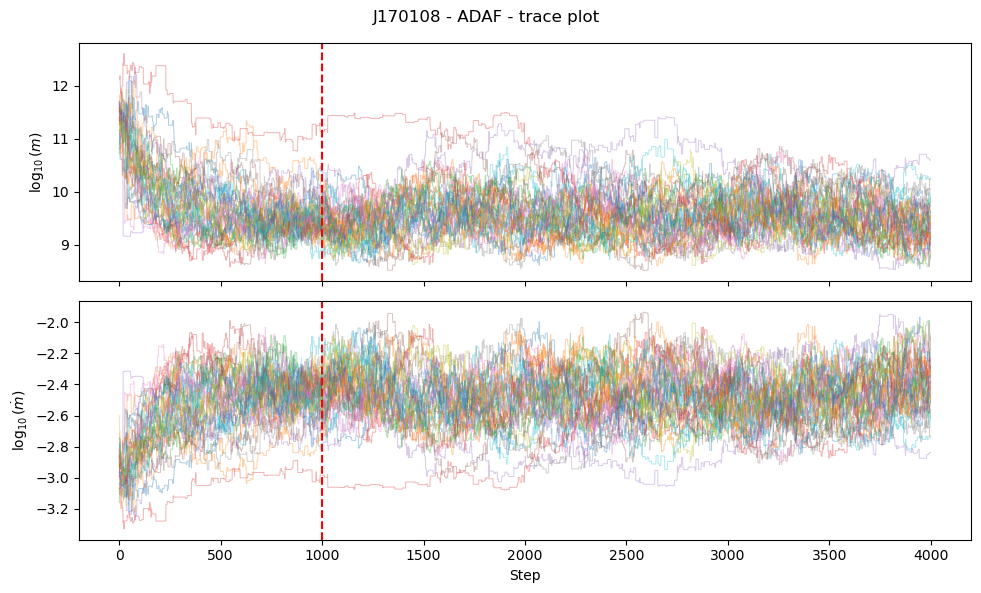

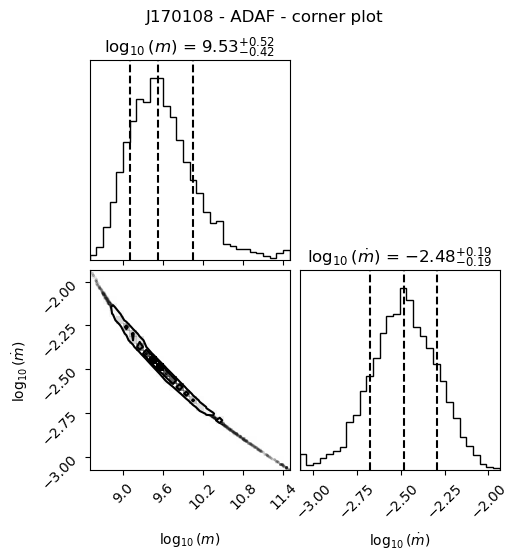

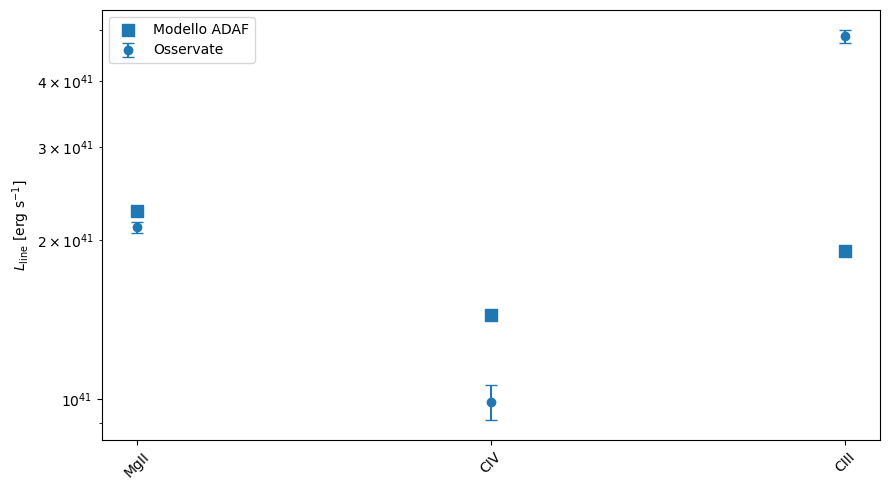

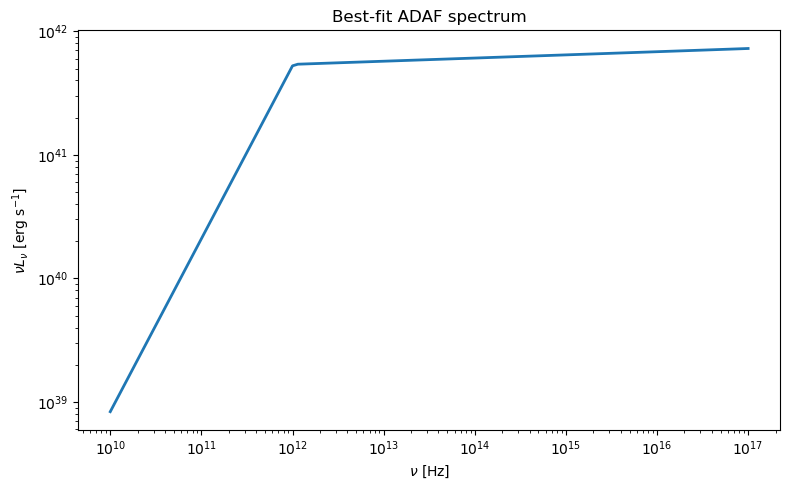

In [1]:
# %%
# !pip install emcee corner scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.special import kv
import emcee
import corner

# ==========================================================
# COSTANTI FISICHE
# ==========================================================
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma_sb = 5.670374419e-5
Msun = 1.98847e33


# ==========================================================
# FUNZIONI UTILI
# ==========================================================
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None


def leggi_transizioni(file_transizioni):
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=("U50", float, float),
        unpack=True
    )
    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list
    })


def estrai_linee_osservate(row, norm_columns, rel_err):
    risultati = []

    for col in norm_columns:
        valore = row[col]
        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        unc_col = f"{line_name}_norm_unc"

        L_line = valore * 1e42

        if unc_col in row.index and pd.notna(row[unc_col]) and row[unc_col] > 0:
            sigma_L = row[unc_col] * 1e42
        else:
            sigma_L = rel_err * L_line

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line_obs": L_line,
            "sigma_L": sigma_L
        })

    return pd.DataFrame(risultati)


def prepara_dati_blazar(label_target, file_linee, file_transizioni, rel_err):
    df_tab = pd.read_csv(file_linee)
    df_trans = leggi_transizioni(file_transizioni)

    col_name_tab = trova_colonna(
        df_tab,
        ["label", "file_name", "name", "nome", "blazar"]
    )

    norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

    df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()
    df_all["label"] = df_all["label"].astype(str).str.strip()

    label_target_clean = str(label_target).strip()

    df_match = df_all[df_all["label"] == label_target_clean].copy()

    if df_match.empty:
        df_match = df_all[
            df_all["label"].str.contains(label_target_clean, case=False, na=False)
        ].copy()

    if df_match.empty:
        print("Label disponibili:")
        print(df_all["label"].drop_duplicates().sort_values().tolist())
        raise ValueError(f"Nessun blazar trovato per label_target = '{label_target}'")

    if len(df_match) > 1:
        print("Trovati più blazar compatibili:")
        print(df_match["label"].tolist())
        print("Uso il primo della lista.")

    row = df_match.iloc[0]

    df_obs = estrai_linee_osservate(row, norm_columns, rel_err)

    df_obs = df_obs.merge(
        df_trans[["line_name", "E_ion", "nu_ion"]],
        on="line_name",
        how="left"
    )

    df_obs["sigma_L"] = pd.to_numeric(df_obs["sigma_L"], errors="coerce")
    df_obs.loc[
        df_obs["sigma_L"].isna() | (df_obs["sigma_L"] <= 0),
        "sigma_L"
    ] = rel_err * df_obs["L_line_obs"]

    print(f"Blazar selezionato: {row['label']}")
    print(f"Numero linee osservate usate: {len(df_obs)}")

    return df_all, df_trans, df_obs


# ==========================================================
# MODELLO ADAF
# ==========================================================
def bessk(n, x):
    return kv(n, x)


def g_adaf(teta):
    return (
        (1.0 / bessk(2, 1.0 / teta))
        * (2.0 + 2.0 * teta + 1.0 / teta)
        * np.exp(-1.0 / teta)
    )


def temperat(y, mdot, m, beta, cfg):
    alfa = cfg["alfa"]
    rmin = cfg["rmin"]
    rmax = cfg["rmax"]
    delta = cfg["delta"]
    c1 = cfg["c1"]
    c3 = cfg["c3"]
    tnorm = cfg["tnorm"]

    ff = y[2]**2
    xm = 1e3 * y[1]**2
    teta = y[0]**2

    s1 = 1.42e9 * alfa**(-0.5) * np.sqrt(1 - beta) * c1**(-0.5) * c3**0.5
    s2 = 1.19e-13 * xm

    q1 = 1.2e4 * g_adaf(teta) * alfa**(-2) * c1**(-2) * c3 * beta * m * mdot**2 / rmin
    q2 = delta * 9.39e4 * ((1 - beta) / ff) * c3 * m * mdot / rmin
    q = q1 + q2

    nup = s1 * s2 * m**(-0.5) * mdot**0.5 * (teta / tnorm)**2 * rmin**(-5/4)

    psinc = (
        53.0 * (xm / 1000.0)**3 *
        (teta / (1e9 * tnorm))**7 *
        m**0.5 * mdot**1.5
    )

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot

    if tau <= 0 or abig <= 0:
        return [1e99, 1e99, 1e99]

    alfac = -np.log(tau) / np.log(abig)

    graffa = ((6.2e7 * (teta / (1e9 * tnorm))) / (nup * 1e-12))**(1 - alfac) - 1
    pcomp = (psinc / 0.71) / (1 - alfac) * graffa

    if teta < 1:
        f = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        f = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    pbrems = 4.78 * alfa**(-2) * c1**(-2) * np.log(rmax/rmin) * f * m * mdot**2

    f1 = q - psinc - pcomp - pbrems
    f2 = (1 - ff) * 9.39e4 * ((1 - beta) / ff) * c3 * m * mdot / rmin - q

    vv = xm**(1/3)
    f3 = (
        vv + 1.852*np.log(vv)
        - 10.36
        - 0.26*np.log(m*mdot)
        + 0.26*np.log(teta**3 * bessk(2, 1/teta))
    )

    return [f1, f3, f2]


def spectrum_adaf(te, f, xm, m, mdot, beta, cfg):
    alfa = cfg["alfa"]
    rmin = cfg["rmin"]
    rmax = cfg["rmax"]
    c1 = cfg["c1"]
    c3 = cfg["c3"]
    tnorm = cfg["tnorm"]

    numin = cfg["nu_min_adaf"]
    numax = cfg["nu_max_adaf"]
    num = cfg["Nnu"]

    lnu = np.linspace(np.log10(numin), np.log10(numax), num)
    nu = 10**lnu

    teta = tnorm * te

    s1 = 1.42e9 * alfa**(-0.5) * np.sqrt(1 - beta) * c1**(-0.5) * c3**0.5
    s2 = 1.19e-13 * xm
    s3 = 1.05e-24

    abig = 1 + 4*teta + 16*teta**2
    tau = 23.87 * mdot
    alfac = -np.log(tau) / np.log(abig)

    lnup = np.log10(s1 * s2 * m**(-0.5) * mdot**0.5 * te**2 * rmin**(-5/4))
    lnucmax = np.log10(te) + 10.796

    llsinc = (
        3*np.log10(s1*s2)
        + np.log10(s3)
        - (7/4)*np.log10(rmin)
        + np.log10(m**0.5 * mdot**1.5)
        + 7*np.log10(te)
    )

    lls = np.zeros(num)
    llc = np.zeros(num)
    llb = np.zeros(num)

    if teta < 1:
        fb = 4*np.sqrt(2*teta/np.pi**3) * (1 + 1.781*teta**1.34)
    else:
        fb = (9*teta/(2*np.pi)) * (np.log(1.123*teta + 0.48) + 1.5)

    for i in range(num):
        if lnu[i] < lnup:
            lls[i] = (
                np.log10(s3)
                + (8/5)*np.log10(s1*s2)
                + np.log10(m**(6/5) * mdot**(4/5))
                + (21/5)*np.log10(te)
                + (2/5)*lnu[i]
            )

        if lnu[i] > lnup:
            base = llsinc + (alfac - 1)*lnup - alfac*lnu[i]
            cutoff = -(10**(lnu[i] - lnucmax)) / np.log(10)
            llc[i] = base + cutoff

        base_b = (
            24.36
            - 2*np.log10(alfa*c1)
            + np.log10(np.log(rmax/rmin) * fb)
            - np.log10(te)
            + np.log10(m * mdot**2)
        )

        cutoff_b = -(4.8e-11 * nu[i] / te) / np.log(10)
        llb[i] = base_b + cutoff_b

    flux = 10**lls + 10**llc + 10**llb
    log_nuLnu = lnu + np.log10(flux)

    return lnu, log_nuLnu


def specdata(m, mdot, beta, cfg, verbose=False):
    if verbose:
        print(f"ADAF -> m={m:.3e}, mdot={mdot:.3e}, beta={beta}")

    y0 = cfg["root_y0"]

    sol = root(
        temperat,
        y0,
        args=(mdot, m, beta, cfg),
        tol=cfg["root_tol"]
    )

    if not sol.success:
        raise RuntimeError(f"Root non converge per m={m:.3e}, mdot={mdot:.3e}")

    y = sol.x

    teta = y[0]**2
    te = teta / cfg["tnorm"]
    xm = 1e3 * y[1]**2
    f = y[2]**2

    lnu, log_nuLnu = spectrum_adaf(te, f, xm, m, mdot, beta, cfg)

    nu = 10**lnu
    logLnu = log_nuLnu - lnu
    Lnu = 10**logLnu
    nuLnu = nu * Lnu

    info = {
        "m": m,
        "mdot": mdot,
        "beta": beta,
        "te": te,
        "xm": xm,
        "f": f,
        "root_success": sol.success
    }

    return nu, Lnu, nuLnu, info


def costruisci_spettro_adaf(MBH_solar, mdot_edd, cfg):
    beta = cfg["beta_adaf"]

    nu, Lnu, nuLnu, info = specdata(
        m=MBH_solar,
        mdot=mdot_edd,
        beta=beta,
        cfg=cfg,
        verbose=False
    )

    mask = (
        np.isfinite(nu) &
        np.isfinite(Lnu) &
        np.isfinite(nuLnu) &
        (nu > 0) &
        (Lnu >= 0)
    )

    nu = nu[mask]
    Lnu = Lnu[mask]
    nuLnu = nuLnu[mask]

    if len(nu) < 2:
        raise RuntimeError("Spettro ADAF non valido dopo filtering")

    idx = np.argsort(nu)

    return nu[idx], Lnu[idx], nuLnu[idx], info


def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max):
    risultati = []

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        nu_ion = row["nu_ion"]
        E_ion = row["E_ion"]

        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)

            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion
        })

    return pd.DataFrame(risultati)


def predici_linee_da_modello_adaf(logm, logmdot, df_trans, cfg):
    m = 10**logm
    mdot = 10**logmdot

    nu, Lnu, nuLnu, info = costruisci_spettro_adaf(
        MBH_solar=m,
        mdot_edd=mdot,
        cfg=cfg
    )

    df_lion = calcola_lion_per_transizioni(
        nu,
        Lnu,
        df_trans,
        nu_max=cfg["nu_max_ion"]
    )

    df_lion["L_line_mod"] = cfg["cf_blr"] * df_lion["L_ion"]

    return df_lion


# ==========================================================
# PRIOR, LIKELIHOOD, POSTERIOR
# ==========================================================
def log_prior(theta, cfg):
    logm, logmdot = theta

    if not (cfg["logm_min"] < logm < cfg["logm_max"]):
        return -np.inf

    if not (cfg["logmdot_min"] < logmdot < cfg["logmdot_max"]):
        return -np.inf

    return 0.0


def log_likelihood(theta, df_obs, df_trans, cfg):
    logm, logmdot = theta

    try:
        df_mod = predici_linee_da_modello_adaf(
            logm=logm,
            logmdot=logmdot,
            df_trans=df_trans,
            cfg=cfg
        )
    except Exception:
        return -np.inf

    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    df_cmp = df_cmp[
        df_cmp["L_line_obs"].notna() &
        df_cmp["sigma_L"].notna() &
        df_cmp["L_line_mod"].notna() &
        np.isfinite(df_cmp["L_line_mod"]) &
        (df_cmp["L_line_mod"] >= 0) &
        (df_cmp["sigma_L"] > 0)
    ].copy()

    if len(df_cmp) == 0:
        return -np.inf

    resid = df_cmp["L_line_obs"].values - df_cmp["L_line_mod"].values
    sigma = df_cmp["sigma_L"].values

    if not np.all(np.isfinite(resid)) or not np.all(np.isfinite(sigma)):
        return -np.inf

    loglike = -0.5 * np.sum(
        (resid / sigma)**2 + np.log(2 * np.pi * sigma**2)
    )

    return loglike


def log_posterior(theta, df_obs, df_trans, cfg):
    lp = log_prior(theta, cfg)

    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(theta, df_obs, df_trans, cfg)

    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


# ==========================================================
# EMCEE
# ==========================================================
def inizializza_walkers(cfg):
    rng = np.random.default_rng(cfg["random_seed"])

    pos = []

    while len(pos) < cfg["nwalkers"]:
        trial = np.array([
            rng.normal(cfg["guess_logm"], cfg["spread_logm"]),
            rng.normal(cfg["guess_logmdot"], cfg["spread_logmdot"])
        ])

        if np.isfinite(log_prior(trial, cfg)):
            pos.append(trial)

    return np.array(pos)


def run_emcee_adaf(df_obs, df_trans, cfg):
    ndim = 2

    initial_pos = inizializza_walkers(cfg)

    sampler = emcee.EnsembleSampler(
        cfg["nwalkers"],
        ndim,
        log_posterior,
        args=(df_obs, df_trans, cfg)
    )

    sampler.run_mcmc(
        initial_pos,
        cfg["nsteps"],
        progress=True
    )

    return sampler


# ==========================================================
# OUTPUT E PLOT
# ==========================================================
def riassumi_posteriore(samples):
    logm = samples[:, 0]
    logmdot = samples[:, 1]

    out = {
        "logm_median": np.median(logm),
        "logm_p16": np.percentile(logm, 16),
        "logm_p84": np.percentile(logm, 84),
        "logmdot_median": np.median(logmdot),
        "logmdot_p16": np.percentile(logmdot, 16),
        "logmdot_p84": np.percentile(logmdot, 84),
    }

    out["m_median"] = 10**out["logm_median"]
    out["mdot_median"] = 10**out["logmdot_median"]

    return out


def plot_trace_emcee(sampler, cfg, titolo=""):
    chain = sampler.get_chain()
    nsteps, nwalkers, ndim = chain.shape

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for i in range(nwalkers):
        axes[0].plot(chain[:, i, 0], alpha=0.35, lw=0.7)
        axes[1].plot(chain[:, i, 1], alpha=0.35, lw=0.7)

    axes[0].axvline(cfg["burn_in"], color="red", linestyle="--")
    axes[1].axvline(cfg["burn_in"], color="red", linestyle="--")

    axes[0].set_ylabel(r"$\log_{10}(m)$")
    axes[1].set_ylabel(r"$\log_{10}(\dot m)$")
    axes[1].set_xlabel("Step")

    fig.suptitle(titolo)
    plt.tight_layout()
    plt.show()


def plot_corner_emcee(samples, cfg, titolo=""):
    samples = np.asarray(samples)
    samples = samples[np.all(np.isfinite(samples), axis=1)]

    if len(samples) == 0:
        print("Samples vuoti: salto corner plot.")
        return

    fig = corner.corner(
        samples,
        labels=[r"$\log_{10}(m)$", r"$\log_{10}(\dot m)$"],
        quantiles=[0.16, 0.50, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        plot_datapoints=True,
        fill_contours=False,
        smooth=None,
        bins=30,
        max_n_ticks=5
    )

    fig.suptitle(titolo, y=1.02)
    plt.show()

def plot_best_fit_linee_adaf(df_obs, df_trans, summary, cfg):
    df_mod = predici_linee_da_modello_adaf(
        logm=summary["logm_median"],
        logmdot=summary["logmdot_median"],
        df_trans=df_trans,
        cfg=cfg
    )

    df_cmp = df_obs.merge(
        df_mod[["line_name", "L_line_mod"]],
        on="line_name",
        how="inner"
    )

    if df_cmp.empty:
        print("Nessuna linea comune tra osservazioni e modello.")
        return

    x = np.arange(len(df_cmp))

    plt.figure(figsize=(9, 5))

    plt.errorbar(
        x,
        df_cmp["L_line_obs"],
        yerr=df_cmp["sigma_L"],
        fmt="o",
        capsize=4,
        label="Osservate"
    )

    plt.scatter(
        x,
        df_cmp["L_line_mod"],
        marker="s",
        s=70,
        label="Modello ADAF"
    )

    plt.yscale("log")
    plt.xticks(x, df_cmp["line_name"], rotation=45)
    plt.ylabel(r"$L_{\rm line}$ [erg s$^{-1}$]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_best_fit_sed_adaf(summary, cfg):
    nu, Lnu, nuLnu, info = costruisci_spettro_adaf(
        MBH_solar=summary["m_median"],
        mdot_edd=summary["mdot_median"],
        cfg=cfg
    )

    plt.figure(figsize=(8, 5))
    plt.plot(nu, nuLnu, lw=2)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"$\nu$ [Hz]")
    plt.ylabel(r"$\nu L_\nu$ [erg s$^{-1}$]")
    plt.title("Best-fit ADAF spectrum")
    plt.tight_layout()
    plt.show()


def stampa_diagnostica(sampler, cfg):
    acc_frac = np.mean(sampler.acceptance_fraction)

    print(f"Acceptance fraction media = {acc_frac:.3f}")

    try:
        tau = sampler.get_autocorr_time()
        print("Autocorrelation time:", tau)
        print("Nsteps / tau:", cfg["nsteps"] / tau)
    except Exception as e:
        print("Autocorrelation time non stimabile:")
        print(e)


# ==========================================================
# FIT COMPLETO
# ==========================================================
def fit_blazar_mcmc_adaf(cfg):
    df_all, df_trans, df_obs = prepara_dati_blazar(
        label_target=cfg["label_target"],
        file_linee=cfg["file_linee"],
        file_transizioni=cfg["file_transizioni"],
        rel_err=cfg["rel_err"]
    )

    sampler = run_emcee_adaf(df_obs, df_trans, cfg)

    chain = sampler.get_chain()
    log_prob = sampler.get_log_prob()

    flat_samples = sampler.get_chain(
        discard=cfg["burn_in"],
        thin=cfg["thin"],
        flat=True
    )

    summary = riassumi_posteriore(flat_samples)

    print("=" * 80)
    print(f"Blazar: {cfg['label_target']}")
    print("Regime: ADAF")
    print(f"Numero walkers = {cfg['nwalkers']}")
    print(f"Numero steps   = {cfg['nsteps']}")
    print(f"Burn-in        = {cfg['burn_in']}")
    print(f"Thin           = {cfg['thin']}")
    print()
    print(f"log10(m)    = {summary['logm_median']:.3f} "
          f"[{summary['logm_p16']:.3f}, {summary['logm_p84']:.3f}]")
    print(f"log10(mdot) = {summary['logmdot_median']:.3f} "
          f"[{summary['logmdot_p16']:.3f}, {summary['logmdot_p84']:.3f}]")
    print(f"m_median    = {summary['m_median']:.3e} Msun")
    print(f"mdot_median = {summary['mdot_median']:.3e}")
    print("=" * 80)

    stampa_diagnostica(sampler, cfg)

    plot_trace_emcee(
        sampler,
        cfg,
        titolo=f"{cfg['label_target']} - ADAF - trace plot"
    )

    plot_corner_emcee(
        flat_samples,
        cfg,
        titolo=f"{cfg['label_target']} - ADAF - corner plot"
    )

    plot_best_fit_linee_adaf(
        df_obs=df_obs,
        df_trans=df_trans,
        summary=summary,
        cfg=cfg
    )

    plot_best_fit_sed_adaf(summary, cfg)

    return {
        "df_obs": df_obs,
        "df_trans": df_trans,
        "sampler": sampler,
        "chain": chain,
        "log_prob": log_prob,
        "flat_samples": flat_samples,
        "summary": summary,
        "acceptance_fraction_mean": np.mean(sampler.acceptance_fraction)
    }


# %%
# ==========================================================
# CONFIGURAZIONE UNICA DA MODIFICARE
# ==========================================================
CFG = {
    # -----------------------------
    # File input
    # -----------------------------
    "file_linee": "Tab_completa_revisione.csv",
    "file_transizioni": "dati.asc",

    # -----------------------------
    # Blazar da fittare
    # -----------------------------
    "label_target": "J170108",

    # -----------------------------
    # Parametri ADAF
    # -----------------------------
    "alfa": 0.3,
    "rmin": 3.0,
    "rmax": 1000.0,
    "delta": 0.0,
    "beta_adaf": 0.5,
    "c1": 0.5,
    "c3": 0.3,
    "tnorm": 1.68e-10,

    # -----------------------------
    # Griglia frequenze ADAF
    # -----------------------------
    "Nnu": 120,
    "nu_min_adaf": 1e10,
    "nu_max_adaf": 1e17,
    "nu_max_ion": 1e17,

    # -----------------------------
    # Assunzioni BLR
    # -----------------------------
    "cf_blr": 0.1,                           
    "rel_err": 0.20,

    # -----------------------------
    # Prior ADAF
    # -----------------------------
    "logm_min": 8.5,
    "logm_max": 13.0,      # prima 12.0: troppo stretto
    "logmdot_min": -4.0,   # basta per vedere bene la coda
    "logmdot_max": -1.5,

    # -----------------------------
    # MCMC veloce
    # -----------------------------
    "nwalkers": 32,
    "nsteps": 4000,
    "burn_in": 1000,
    "thin": 10,

    # -----------------------------
    # Walkers
    # -----------------------------
    "guess_logm": 11.4,
    "guess_logmdot": -2.9,
    "spread_logm": 0.35,
    "spread_logmdot": 0.20,

    # -----------------------------
    # Root solver
    # -----------------------------
    "root_y0": [0.5, 1.0, 0.99],
    "root_tol": 1e-10,

    # -----------------------------
    # Random seed
    # -----------------------------
    "random_seed": 42,
}


# %%
# ==========================================================
# RUN
# ==========================================================
ris_adaf = fit_blazar_mcmc_adaf(CFG)